# Weather and National Park Visitation

## Evidence from 18 western parks, with a Glacier National Park case study

**Portfolio objective:** demonstrate a reproducible public-data pipeline, tourism-focused visualization, and an econometric analysis that is useful to destination researchers and managers.

**Research question:** after accounting for each park's normal seasonality and shocks shared across years, how are unusually warm or wet months associated with recreation visits?

### Executive approach

This notebook combines two official public sources:

1. **National Park Service (NPS):** monthly recreation visits from the [Visitor Use Statistics Data Package](https://catalog.data.gov/dataset/nps-visitor-use-statistics-data-package-2024).
2. **NASA POWER:** gridded monthly temperature and precipitation requested from the [Monthly API](https://power.larc.nasa.gov/docs/services/api/temporal/monthly/).

The main model includes **park-by-calendar-month fixed effects** and **year fixed effects**. This compares, for example, an unusually warm June at Glacier with other Junes at Glacier, while controlling for broad annual travel shocks. Standard errors are clustered by park.

> The design estimates conditional associations. It does not establish a complete causal effect of weather on travel.

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf
from IPython.display import Markdown, display

from src.tourism_pipeline import (
    END_YEAR,
    NPS_CATALOG_URL,
    PARKS,
    POWER_DOCS_URL,
    START_YEAR,
    build_analysis_panel,
)

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 120, "axes.titleweight": "bold"})

COLORS = {
    "navy": "#19324D",
    "teal": "#2A7F7F",
    "gold": "#D49A2A",
    "red": "#B6534E",
    "gray": "#6B7280",
}

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

## 1. Reproducible data pipeline

The pipeline in `src/tourism_pipeline.py` performs four steps:

- downloads and locally caches the approximately 70 MB NPS source CSV;
- requests two monthly weather variables for each park from NASA POWER;
- validates a complete, unique park-month panel; and
- writes a compact processed CSV for reuse.

No API key is required. Cached raw files make later runs fast and reduce avoidable requests.

In [2]:
panel = build_analysis_panel()

source_audit = pd.DataFrame(
    [
        {
            "source": "National Park Service",
            "measure": "Monthly recreation visits (TRV)",
            "coverage_used": f"{START_YEAR}-{END_YEAR}",
            "access": NPS_CATALOG_URL,
        },
        {
            "source": "NASA POWER",
            "measure": "Monthly T2M and PRECTOTCORR",
            "coverage_used": f"{START_YEAR}-{END_YEAR}",
            "access": POWER_DOCS_URL,
        },
    ]
)
source_audit

,source,measure,coverage_used,access
0,National Park Service,Monthly recreation visits (TRV),2005-2024,https://catalog.data.gov/dataset/nps-visitor-u...
1,NASA POWER,Monthly T2M and PRECTOTCORR,2005-2024,https://power.larc.nasa.gov/docs/services/api/...


In [3]:
display(panel.head())

expected_rows = len(PARKS) * (END_YEAR - START_YEAR + 1) * 12
quality_checks = pd.Series(
    {
        "rows": len(panel),
        "expected rows": expected_rows,
        "parks": panel["park_code"].nunique(),
        "months": panel["date"].nunique(),
        "duplicate park-months": panel.duplicated(["park_code", "date"]).sum(),
        "missing cells": int(panel.isna().sum().sum()),
        "zero-visit months": int(panel["recreation_visits"].eq(0).sum()),
    },
    name="value",
).to_frame()
quality_checks

,park_code,year,month,recreation_visits,temp_c,precip_mm_day,park_name,state,latitude,longitude,date
0,ARCH,2005,1,9894,0.99,2.08,Arches,UT,38.73,-109.59,2005-01-01
1,ARCH,2005,2,16168,1.58,1.14,Arches,UT,38.73,-109.59,2005-02-01
2,ARCH,2005,3,62843,3.69,1.25,Arches,UT,38.73,-109.59,2005-03-01
3,ARCH,2005,4,71709,8.72,0.62,Arches,UT,38.73,-109.59,2005-04-01
4,ARCH,2005,5,111718,15.14,0.38,Arches,UT,38.73,-109.59,2005-05-01


,value
rows,4320
expected rows,4320
parks,18
months,240
duplicate park-months,0
missing cells,0
zero-visit months,19


### Measures used

- `recreation_visits`: NPS recreation visits, not unique visitors. A person who exits and returns on another day can generate another visit.
- `temp_c`: NASA POWER monthly mean air temperature at 2 meters, in degrees Celsius.
- `precip_mm_day`: NASA POWER corrected precipitation, expressed as the month's average millimeters per day.

The selected coordinate approximates a central visitor-use area for each park. This is appropriate for a portfolio-scale analysis, but a production study could use multiple grid cells for geographically large parks.

In [4]:
# Use non-2020 observations to define each park-month's normal weather.
climatology = (
    panel.loc[panel["year"].ne(2020)]
    .groupby(["park_code", "month"], as_index=False)[["temp_c", "precip_mm_day"]]
    .mean()
    .rename(columns={"temp_c": "normal_temp_c", "precip_mm_day": "normal_precip"})
)

df = panel.merge(climatology, on=["park_code", "month"], validate="many_to_one")
df["temp_anom_c"] = df["temp_c"] - df["normal_temp_c"]
df["precip_anom_mm_day"] = df["precip_mm_day"] - df["normal_precip"]
df["log_visits"] = np.log1p(df["recreation_visits"])
df["park_month"] = df["park_code"] + "_" + df["month"].astype(str).str.zfill(2)

TEMP_BANDS = ["Cold (<5 C)", "Cool (5-15 C)", "Mild (15-22 C)", "Hot (>22 C)"]
df["temp_band"] = pd.cut(
    df["normal_temp_c"],
    bins=[-np.inf, 5, 15, 22, np.inf],
    labels=TEMP_BANDS,
    ordered=True,
)

analysis = df.loc[df["year"].ne(2020)].copy()
analysis[["recreation_visits", "temp_anom_c", "precip_anom_mm_day"]].describe().T

,count,mean,std,min,25%,50%,75%,max
recreation_visits,"4,104.00","181,947.37","199,054.56",0.00,"43,367.50","105,044.00","239,161.50","1,080,767.00"
temp_anom_c,"4,104.00",-0.00,1.65,-9.48,-1.07,0.06,1.04,7.15
precip_anom_mm_day,"4,104.00",-0.00,1.23,-7.02,-0.48,-0.10,0.37,11.05


## 2. Descriptive tourism patterns

National-park demand is strongly seasonal, and the shape of that seasonality differs across parks. A useful econometric specification must account for those park-specific patterns rather than treating July at Glacier as comparable to July at Death Valley.

**Glacier recorded 3,208,755 recreation visits in 2024.** The 18-park sample recorded 47,870,623.

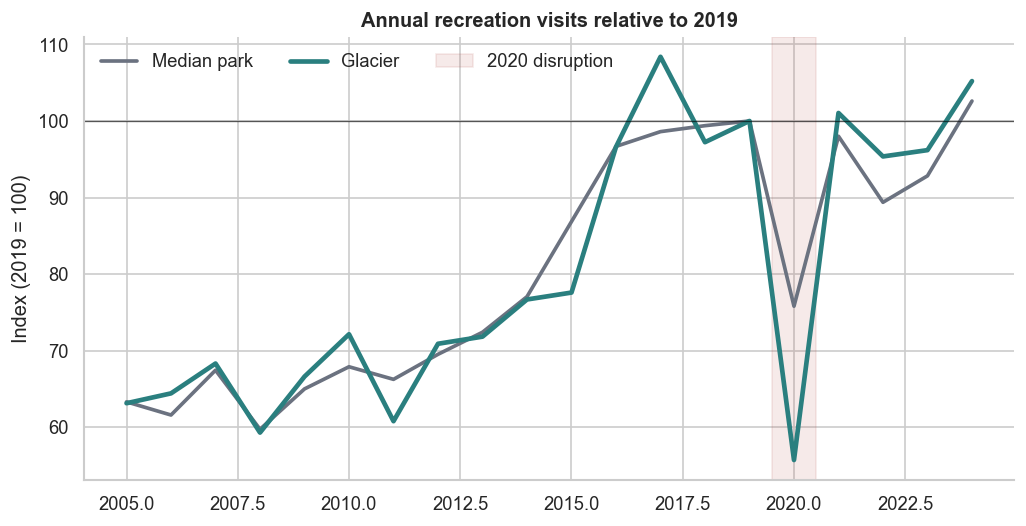

In [5]:
annual = (
    panel.groupby(["park_code", "park_name", "year"], as_index=False)["recreation_visits"]
    .sum()
)

glacier_2024 = annual.query("park_code == 'GLAC' and year == 2024")["recreation_visits"].iloc[0]
sample_2024 = annual.query("year == 2024")["recreation_visits"].sum()
display(
    Markdown(
        f"**Glacier recorded {glacier_2024:,.0f} recreation visits in 2024.** "
        f"The 18-park sample recorded {sample_2024:,.0f}."
    )
)

annual_index = annual.merge(
    annual.query("year == 2019")[["park_code", "recreation_visits"]].rename(
        columns={"recreation_visits": "visits_2019"}
    ),
    on="park_code",
    validate="many_to_one",
)
annual_index["index_2019_100"] = 100 * annual_index["recreation_visits"] / annual_index["visits_2019"]

median_index = annual_index.groupby("year")["index_2019_100"].median()
glacier_index = annual_index.query("park_code == 'GLAC'").set_index("year")["index_2019_100"]

fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot(median_index.index, median_index, color=COLORS["gray"], linewidth=2.2, label="Median park")
ax.plot(glacier_index.index, glacier_index, color=COLORS["teal"], linewidth=2.8, label="Glacier")
ax.axhline(100, color="black", linewidth=0.8, alpha=0.6)
ax.axvspan(2019.5, 2020.5, color=COLORS["red"], alpha=0.12, label="2020 disruption")
ax.set(title="Annual recreation visits relative to 2019", xlabel="", ylabel="Index (2019 = 100)")
ax.legend(frameon=False, ncol=3)
sns.despine()
plt.show()

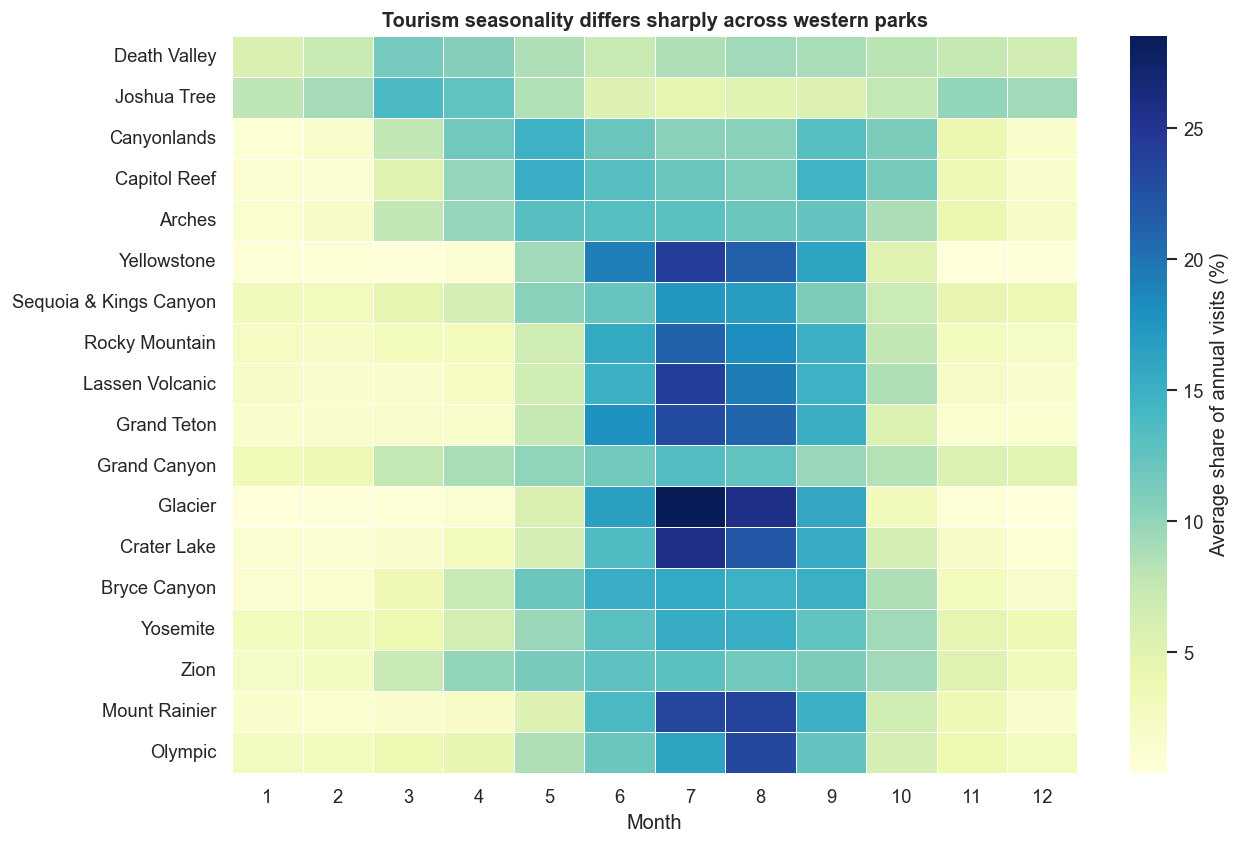

In [6]:
seasonal = panel.loc[panel["year"].ne(2020)].copy()
seasonal["annual_visits"] = seasonal.groupby(["park_code", "year"])["recreation_visits"].transform("sum")
seasonal["monthly_share"] = seasonal["recreation_visits"] / seasonal["annual_visits"]
seasonal_profile = (
    seasonal.groupby(["park_name", "month"])["monthly_share"]
    .mean()
    .unstack("month")
)
seasonal_profile = seasonal_profile.loc[seasonal_profile.idxmax(axis=1).sort_values().index]

fig, ax = plt.subplots(figsize=(11, 7.2))
sns.heatmap(
    100 * seasonal_profile,
    cmap="YlGnBu",
    linewidths=0.35,
    cbar_kws={"label": "Average share of annual visits (%)"},
    ax=ax,
)
ax.set(title="Tourism seasonality differs sharply across western parks", xlabel="Month", ylabel="")
plt.tight_layout()
plt.show()

## 3. Econometric design

The estimating equation is:

$$\log(Visits_{pmy}+1) = \alpha_{pm} + \gamma_y + \sum_b \beta_b(TempAnomaly_{pmy} \times Band_{pm,b}) + \delta PrecipAnomaly_{pmy} + \epsilon_{pmy}$$

where:

- $\alpha_{pm}$ is a fixed effect for each park and calendar month;
- $\gamma_y$ is a year fixed effect;
- temperature-anomaly effects vary with the park-month's normal climate band; and
- standard errors are clustered by park.

The primary model excludes 2020 because closure rules and count procedures changed abruptly and unevenly across parks. Year effects absorb common demand shocks in the remaining years.

In [7]:
MODEL_FORMULA = (
    "log_visits ~ 0 + temp_anom_c:C(temp_band) + precip_anom_mm_day "
    "+ C(park_month) + C(year)"
)

def fit_fixed_effects_model(data):
    return smf.ols(MODEL_FORMULA, data=data).fit(
        cov_type="cluster",
        cov_kwds={"groups": data["park_code"], "use_correction": True},
    )

model = fit_fixed_effects_model(analysis)

model_diagnostics = pd.Series(
    {
        "observations": int(model.nobs),
        "parks / clusters": analysis["park_code"].nunique(),
        "park-month fixed effects": analysis["park_month"].nunique(),
        "years": analysis["year"].nunique(),
        "R-squared": model.rsquared,
        "adjusted R-squared": model.rsquared_adj,
    },
    name="value",
).to_frame()
model_diagnostics

,value
observations,"4,104.00"
parks / clusters,18.00
park-month fixed effects,216.00
years,19.00
R-squared,0.90
adjusted R-squared,0.89


In [8]:
def model_effects(fitted_model):
    rows = []
    confidence = fitted_model.conf_int()
    for band in TEMP_BANDS:
        term = f"temp_anom_c:C(temp_band)[{band}]"
        rows.append(
            {
                "term": band,
                "unit change": "+1 C versus normal",
                "coefficient": fitted_model.params[term],
                "std_error": fitted_model.bse[term],
                "ci_low": confidence.loc[term, 0],
                "ci_high": confidence.loc[term, 1],
                "p_value": fitted_model.pvalues[term],
            }
        )

    term = "precip_anom_mm_day"
    rows.append(
        {
            "term": "Precipitation",
            "unit change": "+1 mm/day versus normal",
            "coefficient": fitted_model.params[term],
            "std_error": fitted_model.bse[term],
            "ci_low": confidence.loc[term, 0],
            "ci_high": confidence.loc[term, 1],
            "p_value": fitted_model.pvalues[term],
        }
    )
    effects = pd.DataFrame(rows)
    for column in ["coefficient", "ci_low", "ci_high"]:
        effects[column.replace("coefficient", "effect_pct").replace("ci_low", "ci_low_pct").replace("ci_high", "ci_high_pct")] = 100 * (np.exp(effects[column]) - 1)
    return effects

effects = model_effects(model)
effects[["term", "unit change", "effect_pct", "ci_low_pct", "ci_high_pct", "p_value"]].round(3)

,term,unit change,effect_pct,ci_low_pct,ci_high_pct,p_value
0,Cold (<5 C),+1 C versus normal,3.17,2.39,3.95,0.00
1,Cool (5-15 C),+1 C versus normal,1.40,0.27,2.54,0.01
2,Mild (15-22 C),+1 C versus normal,-1.61,-3.00,-0.20,0.03
3,Hot (>22 C),+1 C versus normal,-0.43,-3.35,2.58,0.78
4,Precipitation,+1 mm/day versus normal,-2.96,-4.28,-1.62,0.00


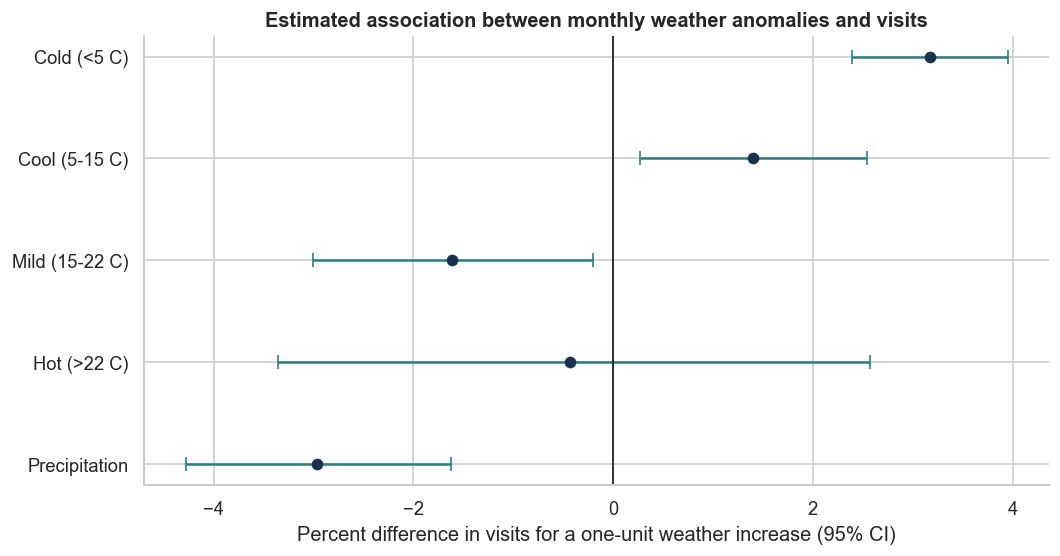

In [9]:
plot_effects = effects.iloc[::-1].reset_index(drop=True)
y = np.arange(len(plot_effects))
xerr = np.vstack(
    [
        plot_effects["effect_pct"] - plot_effects["ci_low_pct"],
        plot_effects["ci_high_pct"] - plot_effects["effect_pct"],
    ]
)

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.errorbar(
    plot_effects["effect_pct"],
    y,
    xerr=xerr,
    fmt="o",
    color=COLORS["navy"],
    ecolor=COLORS["teal"],
    capsize=4,
    markersize=6,
)
ax.axvline(0, color="black", linewidth=0.9)
ax.set_yticks(y, plot_effects["term"])
ax.set(
    title="Estimated association between monthly weather anomalies and visits",
    xlabel="Percent difference in visits for a one-unit weather increase (95% CI)",
    ylabel="",
)
sns.despine()
plt.tight_layout()
plt.show()

In [10]:
cold_effect = effects.loc[effects["term"].eq("Cold (<5 C)"), "effect_pct"].iloc[0]
mild_effect = effects.loc[effects["term"].eq("Mild (15-22 C)"), "effect_pct"].iloc[0]
rain_effect = effects.loc[effects["term"].eq("Precipitation"), "effect_pct"].iloc[0]

display(
    Markdown(
        "### Main result\n\n"
        f"Holding fixed each park's normal monthly pattern and common year shocks, "
        f"a month that is **1 C warmer than normal** is associated with about "
        f"**{cold_effect:.1f}% more visits in normally cold park-months**. "
        f"The estimate becomes **{mild_effect:.1f}% in normally mild months**, "
        "consistent with diminishing or reversing benefits as conditions become warmer. "
        f"An additional **1 mm/day of precipitation** is associated with "
        f"**{abs(rain_effect):.1f}% fewer visits**."
    )
)

### Main result

Holding fixed each park's normal monthly pattern and common year shocks, a month that is **1 C warmer than normal** is associated with about **3.2% more visits in normally cold park-months**. The estimate becomes **-1.6% in normally mild months**, consistent with diminishing or reversing benefits as conditions become warmer. An additional **1 mm/day of precipitation** is associated with **3.0% fewer visits**.

## 4. Glacier National Park application

The table below applies the pooled coefficients to Glacier's 2024 weather anomalies. The final column is a model-based weather association, not a forecast error decomposition or causal estimate. It illustrates how a tourism analyst could turn a panel model into a local monitoring metric.

In [11]:
band_slopes = {
    band: model.params[f"temp_anom_c:C(temp_band)[{band}]"] for band in TEMP_BANDS
}
precip_slope = model.params["precip_anom_mm_day"]

glacier_case = df.query("park_code == 'GLAC' and year == 2024").copy()
glacier_case["temp_slope"] = glacier_case["temp_band"].astype(str).map(band_slopes)
glacier_case["weather_component"] = (
    glacier_case["temp_slope"] * glacier_case["temp_anom_c"]
    + precip_slope * glacier_case["precip_anom_mm_day"]
)
glacier_case["weather_association_pct"] = 100 * (np.exp(glacier_case["weather_component"]) - 1)
glacier_case["month_name"] = glacier_case["date"].dt.strftime("%b")

glacier_case[
    ["month_name", "recreation_visits", "temp_anom_c", "precip_anom_mm_day", "weather_association_pct"]
].rename(
    columns={
        "month_name": "month",
        "recreation_visits": "visits",
        "temp_anom_c": "temperature anomaly (C)",
        "precip_anom_mm_day": "precipitation anomaly (mm/day)",
        "weather_association_pct": "model-associated visit difference (%)",
    }
).round(2)

,month,visits,temperature anomaly (C),precipitation anomaly (mm/day),model-associated visit difference (%)
1668,Jan,13610,-1.02,-0.18,-2.60
1669,Feb,16658,3.30,0.58,8.92
1670,Mar,24073,-0.31,0.03,-1.05
1671,Apr,45056,1.65,-0.08,5.56
1672,May,209556,-0.67,0.70,-2.99
1673,Jun,549591,-0.75,-0.59,0.73
1674,Jul,791717,2.03,-0.28,-2.41
1675,Aug,748996,0.11,1.30,-3.67
1676,Sep,602339,2.71,-0.10,4.16
1677,Oct,165018,2.22,-1.07,10.67


## 5. Robustness and sensitivity

Three checks probe whether the main pattern depends on a single sample choice:

- include the operationally unusual year 2020;
- use only the pre-pandemic period; and
- omit very low-volume months, where closures and small counts can dominate log changes.

In [12]:
robustness_samples = {
    "Primary: exclude 2020": analysis,
    "Include 2020": df,
    "Pre-pandemic: 2005-2019": df.loc[df["year"].le(2019)],
    "Months with 1,000+ visits": analysis.loc[analysis["recreation_visits"].ge(1_000)],
}

robustness_rows = []
for sample_name, sample in robustness_samples.items():
    fitted = fit_fixed_effects_model(sample)
    fitted_effects = model_effects(fitted).set_index("term")
    robustness_rows.append(
        {
            "sample": sample_name,
            "cold temp effect (%)": fitted_effects.loc["Cold (<5 C)", "effect_pct"],
            "cool temp effect (%)": fitted_effects.loc["Cool (5-15 C)", "effect_pct"],
            "mild temp effect (%)": fitted_effects.loc["Mild (15-22 C)", "effect_pct"],
            "hot temp effect (%)": fitted_effects.loc["Hot (>22 C)", "effect_pct"],
            "precipitation effect (%)": fitted_effects.loc["Precipitation", "effect_pct"],
            "observations": int(fitted.nobs),
        }
    )

robustness_table = pd.DataFrame(robustness_rows).set_index("sample")
robustness_table.round(2)

,cold temp effect (%),cool temp effect (%),mild temp effect (%),hot temp effect (%),precipitation effect (%),observations
sample,,,,,,
Primary: exclude 2020,3.17,1.40,-1.61,-0.43,-2.96,4104
Include 2020,3.48,0.41,-0.52,0.78,-4.21,4320
Pre-pandemic: 2005-2019,2.94,1.56,0.04,-1.05,-1.95,3240
"Months with 1,000+ visits",3.24,1.28,-1.18,-2.86,-2.77,4093


In [13]:
# Re-estimate the model 18 times, omitting one park at a time.
leave_one_out = []
for omitted_code, omitted_name in PARKS[["park_code", "park_name"]].itertuples(index=False):
    sample = analysis.loc[analysis["park_code"].ne(omitted_code)]
    fitted = fit_fixed_effects_model(sample)
    fitted_effects = model_effects(fitted).set_index("term")
    leave_one_out.append(
        {
            "omitted_park": omitted_name,
            "cold_temp_effect_pct": fitted_effects.loc["Cold (<5 C)", "effect_pct"],
            "precip_effect_pct": fitted_effects.loc["Precipitation", "effect_pct"],
        }
    )

leave_one_out = pd.DataFrame(leave_one_out)
leave_one_out.describe().loc[["min", "mean", "max"]].round(2)

,cold_temp_effect_pct,precip_effect_pct
min,3.00,-3.53
mean,3.17,-2.97
max,3.43,-2.61


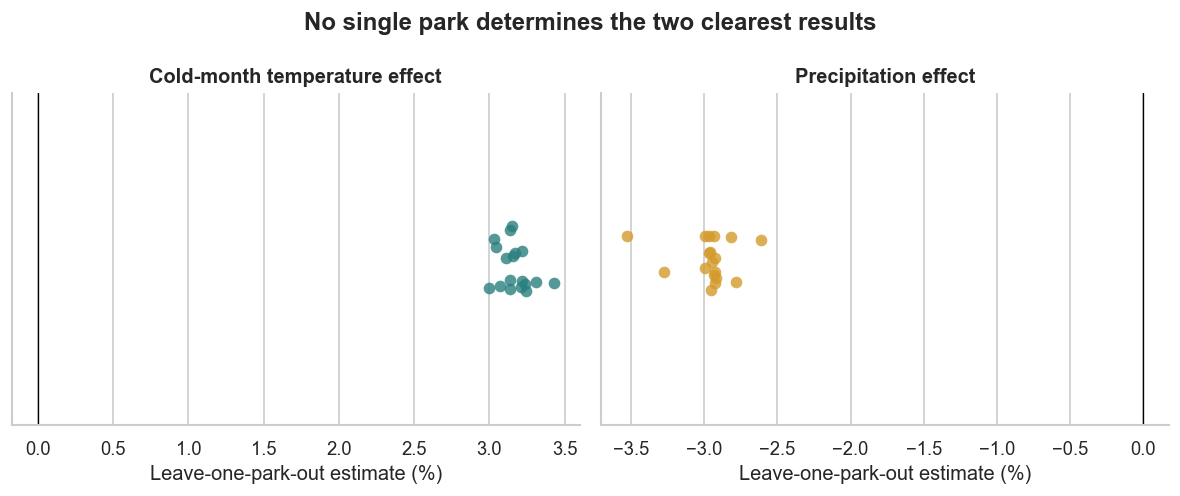

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
for ax, column, title, color in [
    (axes[0], "cold_temp_effect_pct", "Cold-month temperature effect", COLORS["teal"]),
    (axes[1], "precip_effect_pct", "Precipitation effect", COLORS["gold"]),
]:
    sns.stripplot(data=leave_one_out, x=column, color=color, size=7, alpha=0.8, ax=ax)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set(title=title, xlabel="Leave-one-park-out estimate (%)", ylabel="")

fig.suptitle("No single park determines the two clearest results", fontweight="bold")
plt.tight_layout()
sns.despine()
plt.show()

## 6. Implications for tourism research

1. **Use weather relative to local norms.** A 15 C month means something different at Glacier than at Death Valley. Park-by-month fixed effects and anomalies make that comparison explicit.
2. **Expect asymmetric demand responses.** Warmer-than-normal conditions are associated with more visits in cold months, but that benefit weakens or reverses in milder conditions.
3. **Precipitation is operationally relevant.** Short-term precipitation forecasts could complement historical seasonality when planning staffing, visitor messaging, and congestion management.
4. **Keep the inference modest.** The estimates describe visits, not spending, resident sentiment, tax revenue, or employment. Those outcomes would require additional local data.

### Important limitations

- NPS visits are estimated entries, not unique people.
- Count procedures and park access can change over time.
- A single gridded weather point cannot represent all terrain in a large park.
- Weather can operate through road closures, wildfire, smoke, and park operations; these pathways are not separately identified.
- Eighteen park clusters are useful but still a modest number for cluster-robust inference.
- The model is observational and should not be presented as a complete causal estimate.

### Natural extensions

A production study for Montana could merge this demand signal with lodging-tax collections, airport arrivals, short-term rental occupancy, wildfire smoke, or county-level leisure and hospitality employment. The same pipeline and fixed-effects structure provide a starting point.

---

## Reproducibility notes

- Analysis period: January 2005 through December 2024.
- NPS data package DOI: [10.57830/2316688](https://doi.org/10.57830/2316688).
- The NPS package is public domain (CC0).
- Raw data are cached under `data/raw/`; the merged panel is saved under `data/processed/`.
- Re-running the notebook refreshes the processed file from cached raw sources. Set `force=True` in `build_analysis_panel()` to request fresh copies from the fixed source endpoints.